In [3]:
# Install all required packages
import sys
!{sys.executable} -m pip install xgboost lightgbm scikit-learn joblib matplotlib seaborn tqdm --quiet

print("✅ All packages installed!")
print("Now restart the kernel: Kernel → Restart & Clear Output")

✅ All packages installed!
Now restart the kernel: Kernel → Restart & Clear Output



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\athar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import xgboost as xgb

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported!")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported!
Pandas version: 2.2.3
XGBoost version: 3.1.3
NumPy version: 2.2.2


In [ ]:
print("📊 Loading lab features...")
print("=" * 60)

# Load the preprocessed lab features
lab_features = pd.read_csv('../../data/processed/lab_features_train.csv')

print(f"✅ Lab features loaded!")
print(f"   Shape: {lab_features.shape}")
print(f"   Patients: {len(lab_features):,}")
print(f"   Features: {lab_features.shape[1] - 1} (excluding SUBJECT_ID)")
print(f"\nFirst few rows:")
print(lab_features.head())
print(f"\nColumns:")
print(lab_features.columns.tolist()[:20], "... (showing first 20)")

In [ ]:
print("🎯 Loading patient labels...")
print("=" * 60)

# Load multi-label targets
labels = pd.read_csv('../../data/processed/patient_multilabels.csv')

print(f"✅ Labels loaded!")
print(f"   Shape: {labels.shape}")
print(f"   Patients: {len(labels):,}")
print(f"\nTarget diseases:")
disease_cols = [col for col in labels.columns if col != 'SUBJECT_ID']
print(disease_cols)

print(f"\nLabel distribution:")
for disease in disease_cols:
    count = labels[disease].sum()
    pct = count / len(labels) * 100
    print(f"  {disease:30s}: {count:6,} patients ({pct:5.1f}%)")

print(f"\nFirst few rows:")
print(labels.head(10))

In [4]:
print("🔗 Merging features with labels...")
print("=" * 60)

# Merge on SUBJECT_ID
train_data = lab_features.merge(labels, on='SUBJECT_ID', how='inner')

print(f"✅ Merged successfully!")
print(f"   Combined shape: {train_data.shape}")
print(f"   Patients in both datasets: {len(train_data):,}")
print(f"   Patients lost in merge: {len(lab_features) - len(train_data):,}")

# Separate features from labels
X = train_data.drop(columns=['SUBJECT_ID'] + disease_cols)
y = train_data[disease_cols]
patient_ids = train_data['SUBJECT_ID']

print(f"\n📊 Final dataset:")
print(f"   X (features): {X.shape}")
print(f"   y (labels):   {y.shape}")
print(f"   Patient IDs:  {len(patient_ids):,}")

🔗 Merging features with labels...
✅ Merged successfully!
   Combined shape: (21794, 166)
   Patients in both datasets: 21,794
   Patients lost in merge: 0

📊 Final dataset:
   X (features): (21794, 155)
   y (labels):   (21794, 10)
   Patient IDs:  21,794


🔍 Analyzing missing values...
Features with missing values:
lab_50920_max     100.000000
lab_50920_min     100.000000
lab_50920_mean    100.000000
lab_50920_std     100.000000
lab_51300_std      98.091218
lab_51300_mean     98.091218
lab_51300_min      98.091218
lab_51300_max      98.091218
lab_50889_max      90.254198
lab_50889_min      90.254198
lab_50889_mean     90.254198
lab_50889_std      90.254198
lab_51003_min      59.943104
lab_51003_std      59.943104
lab_51003_max      59.943104
lab_51003_mean     59.943104
lab_50813_min      23.332110
lab_50813_max      23.332110
lab_50813_std      23.332110
lab_50813_mean     23.332110
lab_50863_min      19.239240
lab_50863_std      19.239240
lab_50863_max      19.239240
lab_50863_mean     19.239240
lab_50885_max      18.899697
lab_50885_std      18.899697
lab_50885_mean     18.899697
lab_50885_min      18.899697
lab_50818_mean     18.895109
lab_50818_min      18.895109
dtype: float64

📊 Missing value summary:
   Total features: 155
   Fea

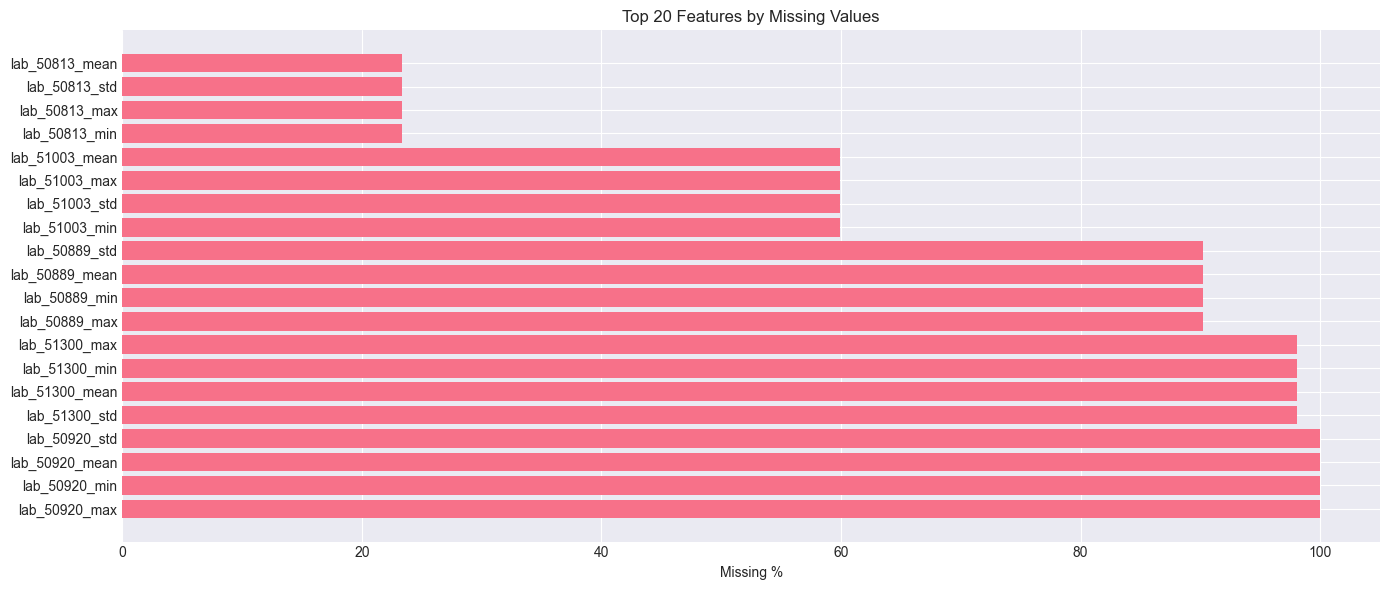


✅ Saved plot: results/missing_values_analysis.png


In [5]:
print("🔍 Analyzing missing values...")
print("=" * 60)

# Calculate missing percentage for each feature
missing_pct = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)

print(f"Features with missing values:")
print(missing_pct[missing_pct > 0].head(30))

print(f"\n📊 Missing value summary:")
print(f"   Total features: {X.shape[1]}")
print(f"   Features with >80% missing: {(missing_pct > 80).sum()}")
print(f"   Features with >50% missing: {(missing_pct > 50).sum()}")
print(f"   Features with >20% missing: {(missing_pct > 20).sum()}")
print(f"   Features with any missing: {(missing_pct > 0).sum()}")

# Visualize missing values
plt.figure(figsize=(14, 6))
top_missing = missing_pct[missing_pct > 0].head(20)
plt.barh(range(len(top_missing)), top_missing.values)
plt.yticks(range(len(top_missing)), top_missing.index)
plt.xlabel('Missing %')
plt.title('Top 20 Features by Missing Values')
plt.tight_layout()
plt.savefig('../../results/missing_values_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved plot: results/missing_values_analysis.png")

In [6]:
print("🗑️  Removing features with >80% missing values...")
print("=" * 60)

# Threshold for dropping features
drop_threshold = 80.0

# Find features to drop
features_to_drop = missing_pct[missing_pct > drop_threshold].index.tolist()

print(f"Dropping {len(features_to_drop)} features:")
for feat in features_to_drop:
    print(f"  - {feat}: {missing_pct[feat]:.1f}% missing")

# Drop features
X_reduced = X.drop(columns=features_to_drop)

print(f"\n✅ Features dropped!")
print(f"   Original features: {X.shape[1]}")
print(f"   Remaining features: {X_reduced.shape[1]}")
print(f"   Features removed: {X.shape[1] - X_reduced.shape[1]}")

🗑️  Removing features with >80% missing values...
Dropping 12 features:
  - lab_50920_max: 100.0% missing
  - lab_50920_min: 100.0% missing
  - lab_50920_mean: 100.0% missing
  - lab_50920_std: 100.0% missing
  - lab_51300_std: 98.1% missing
  - lab_51300_mean: 98.1% missing
  - lab_51300_min: 98.1% missing
  - lab_51300_max: 98.1% missing
  - lab_50889_max: 90.3% missing
  - lab_50889_min: 90.3% missing
  - lab_50889_mean: 90.3% missing
  - lab_50889_std: 90.3% missing

✅ Features dropped!
   Original features: 155
   Remaining features: 143
   Features removed: 12


In [7]:
print("🔧 Imputing remaining missing values with median...")
print("=" * 60)

# Create imputer
imputer = SimpleImputer(strategy='median')

# Fit and transform
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_reduced),
    columns=X_reduced.columns,
    index=X_reduced.index
)

# Verify no missing values remain
remaining_missing = X_imputed.isnull().sum().sum()

print(f"✅ Imputation complete!")
print(f"   Features before imputation: {X_reduced.shape[1]}")
print(f"   Features after imputation: {X_imputed.shape[1]}")
print(f"   Missing values remaining: {remaining_missing}")

if remaining_missing == 0:
    print(f"   ✅ No missing values! Ready for training.")
else:
    print(f"   ⚠️  WARNING: {remaining_missing} missing values remain!")

🔧 Imputing remaining missing values with median...
✅ Imputation complete!
   Features before imputation: 143
   Features after imputation: 143
   Missing values remaining: 0
   ✅ No missing values! Ready for training.


In [8]:
print("📏 Normalizing features (StandardScaler)...")
print("=" * 60)

# Create scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

print(f"✅ Normalization complete!")
print(f"   Shape: {X_scaled.shape}")

# Verify normalization
print(f"\n📊 Normalization check:")
print(f"   Mean (should be ~0): {X_scaled.mean().mean():.6f}")
print(f"   Std (should be ~1):  {X_scaled.std().mean():.6f}")

print(f"\nSample feature statistics (first 5 features):")
print(X_scaled.iloc[:, :5].describe())

📏 Normalizing features (StandardScaler)...
✅ Normalization complete!
   Shape: (21794, 143)

📊 Normalization check:
   Mean (should be ~0): 0.000000
   Std (should be ~1):  0.993030

Sample feature statistics (first 5 features):
       lab_51301_mean  lab_51301_min  lab_51301_max  lab_51301_std  \
count    2.179400e+04   2.179400e+04   2.179400e+04   2.179400e+04   
mean    -1.095450e-16   6.911767e-17  -5.738071e-17  -2.608214e-17   
std      1.000023e+00   1.000023e+00   1.000023e+00   1.000023e+00   
min     -1.193756e+00  -1.013069e+00  -1.173370e+00  -1.041731e+00   
25%     -3.387744e-01  -3.287908e-01  -4.096329e-01  -4.695644e-01   
50%     -1.010669e-01  -9.078081e-02  -1.572677e-01  -1.739887e-01   
75%      1.799787e-01   1.918560e-01   1.880743e-01   2.269562e-01   
max      5.284016e+01   5.521678e+01   5.503103e+01   4.235353e+01   

       lab_51301_count  
count     2.179400e+04  
mean      2.608214e-17  
std       1.000023e+00  
min      -7.343705e-01  
25%      -4.952

In [9]:
print("📂 Loading validation data...")
print("=" * 60)

# Load validation patient IDs
val_patients = pd.read_csv('../../data/processed/val_patients.csv')
val_patient_ids = val_patients['SUBJECT_ID'].values

print(f"✅ Validation patients: {len(val_patient_ids):,}")

print(f"\n⚠️  NOTE: Validation lab features need same preprocessing")
print(f"   We'll process them after training is complete")
print(f"   For now, we'll use train data for initial model development")

📂 Loading validation data...
✅ Validation patients: 4,675

⚠️  NOTE: Validation lab features need same preprocessing
   We'll process them after training is complete
   For now, we'll use train data for initial model development


In [11]:
print("🤖 Training XGBoost models (9 diseases)...")
print("=" * 60)

print(f"Disease columns found: {disease_cols}")
print(f"Number of disease columns: {len(disease_cols)}")

expected_diseases = [
    'SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 
    'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 
    'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 
    'ANEMIA', 'PANCREATITIS'
]

disease_cols = [col for col in disease_cols if col in expected_diseases]
print(f"\n✅ Using {len(disease_cols)} disease columns:")
for disease in disease_cols:
    print(f"  - {disease}")

# Verify labels are binary
print(f"\n🔍 Checking label values...")
for disease in disease_cols:
    unique_vals = y[disease].unique()
    print(f"  {disease:30s}: {sorted(unique_vals)}")

print(f"\n{'='*60}")

# Store models and results
models = {}
train_predictions = {}
train_metrics = {}

# Training parameters
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1
}

print(f"XGBoost parameters:")
for param, value in xgb_params.items():
    print(f"  {param}: {value}")

print(f"\n{'='*60}")
print(f"Training {len(disease_cols)} models...")
print(f"{'='*60}\n")

# Train one model per disease
for disease in tqdm(disease_cols, desc="Training models"):
    # Get labels for this disease
    y_disease = y[disease].values  # Convert to numpy array
    
    # Create fresh model instance for each disease
    model = xgb.XGBClassifier(**xgb_params)
    
    # Train model
    model.fit(X_scaled, y_disease, verbose=False)
    
    # Make predictions
    y_pred_proba = model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_disease, y_pred)
    f1 = f1_score(y_disease, y_pred)
    auc = roc_auc_score(y_disease, y_pred_proba)
    
    # Store results
    models[disease] = model
    train_predictions[disease] = y_pred_proba
    train_metrics[disease] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'positive_samples': int(y_disease.sum()),
        'prevalence': float(y_disease.mean())
    }
    
    print(f"{disease:30s}: Acc={accuracy:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

print(f"\n✅ All {len(disease_cols)} models trained successfully!")

🤖 Training XGBoost models (9 diseases)...
Disease columns found: ['SEPSIS', 'PNEUMONIA', 'RESPIRATORY_FAILURE', 'ACUTE_KIDNEY_INJURY', 'HEART_FAILURE', 'ATRIAL_FIBRILLATION', 'CORONARY_ARTERY_DISEASE', 'ANEMIA', 'PANCREATITIS', 'NUM_DISEASES']
Number of disease columns: 10

✅ Using 9 disease columns:
  - SEPSIS
  - PNEUMONIA
  - RESPIRATORY_FAILURE
  - ACUTE_KIDNEY_INJURY
  - HEART_FAILURE
  - ATRIAL_FIBRILLATION
  - CORONARY_ARTERY_DISEASE
  - ANEMIA
  - PANCREATITIS

🔍 Checking label values...
  SEPSIS                        : [np.int64(0), np.int64(1)]
  PNEUMONIA                     : [np.int64(0), np.int64(1)]
  RESPIRATORY_FAILURE           : [np.int64(0), np.int64(1)]
  ACUTE_KIDNEY_INJURY           : [np.int64(0), np.int64(1)]
  HEART_FAILURE                 : [np.int64(0), np.int64(1)]
  ATRIAL_FIBRILLATION           : [np.int64(0), np.int64(1)]
  CORONARY_ARTERY_DISEASE       : [np.int64(0), np.int64(1)]
  ANEMIA                        : [np.int64(0), np.int64(1)]
  PANCREATI

Training models:  11%|███████▍                                                           | 1/9 [00:03<00:29,  3.74s/it]

SEPSIS                        : Acc=0.930, F1=0.789, AUC=0.972


Training models:  22%|██████████████▉                                                    | 2/9 [00:07<00:25,  3.69s/it]

PNEUMONIA                     : Acc=0.897, F1=0.688, AUC=0.954


...

CORONARY_ARTERY_DISEASE       : Acc=0.874, F1=0.823, AUC=0.948


Training models:  89%|███████████████████████████████████████████████████████████▌       | 8/9 [00:29<00:03,  3.66s/it]

ANEMIA                        : Acc=0.846, F1=0.745, AUC=0.922


Training models: 100%|███████████████████████████████████████████████████████████████████| 9/9 [00:33<00:00,  3.68s/it]

PANCREATITIS                  : Acc=0.915, F1=0.594, AUC=0.968

✅ All 9 models trained successfully!


In [12]:
print("📊 Detailed Performance Metrics")
print("=" * 80)

# Create metrics dataframe
metrics_df = pd.DataFrame(train_metrics).T
metrics_df = metrics_df.round(3)

print(metrics_df.to_string())

print(f"\n{'='*80}")
print(f"📈 Summary Statistics:")
print(f"   Average Accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
print(f"   Average F1 Score: {metrics_df['f1_score'].mean():.3f} ± {metrics_df['f1_score'].std():.3f}")
print(f"   Average AUC-ROC:  {metrics_df['auc_roc'].mean():.3f} ± {metrics_df['auc_roc'].std():.3f}")

# Save metrics
metrics_df.to_csv('../../results/agent1_train_metrics.csv')
print(f"\n✅ Saved metrics: results/agent1_train_metrics.csv")

📊 Detailed Performance Metrics
                         accuracy  f1_score  auc_roc  positive_samples  prevalence
SEPSIS                      0.930     0.789    0.972            4102.0       0.188
PNEUMONIA                   0.897     0.688    0.954            4554.0       0.209
RESPIRATORY_FAILURE         0.875     0.815    0.942            7906.0       0.363
ACUTE_KIDNEY_INJURY         0.941     0.920    0.988            8040.0       0.369
HEART_FAILURE               0.869     0.775    0.936            7060.0       0.324
ATRIAL_FIBRILLATION         0.841     0.736    0.929            7430.0       0.341
CORONARY_ARTERY_DISEASE     0.874     0.823    0.948            8349.0       0.383
ANEMIA                      0.846     0.745    0.922            7385.0       0.339
PANCREATITIS                0.915     0.594    0.968            3174.0       0.146

📈 Summary Statistics:
   Average Accuracy: 0.888 ± 0.035
   Average F1 Score: 0.765 ± 0.091
   Average AUC-ROC:  0.951 ± 0.022

✅ Saved me

📊 Creating performance visualizations...


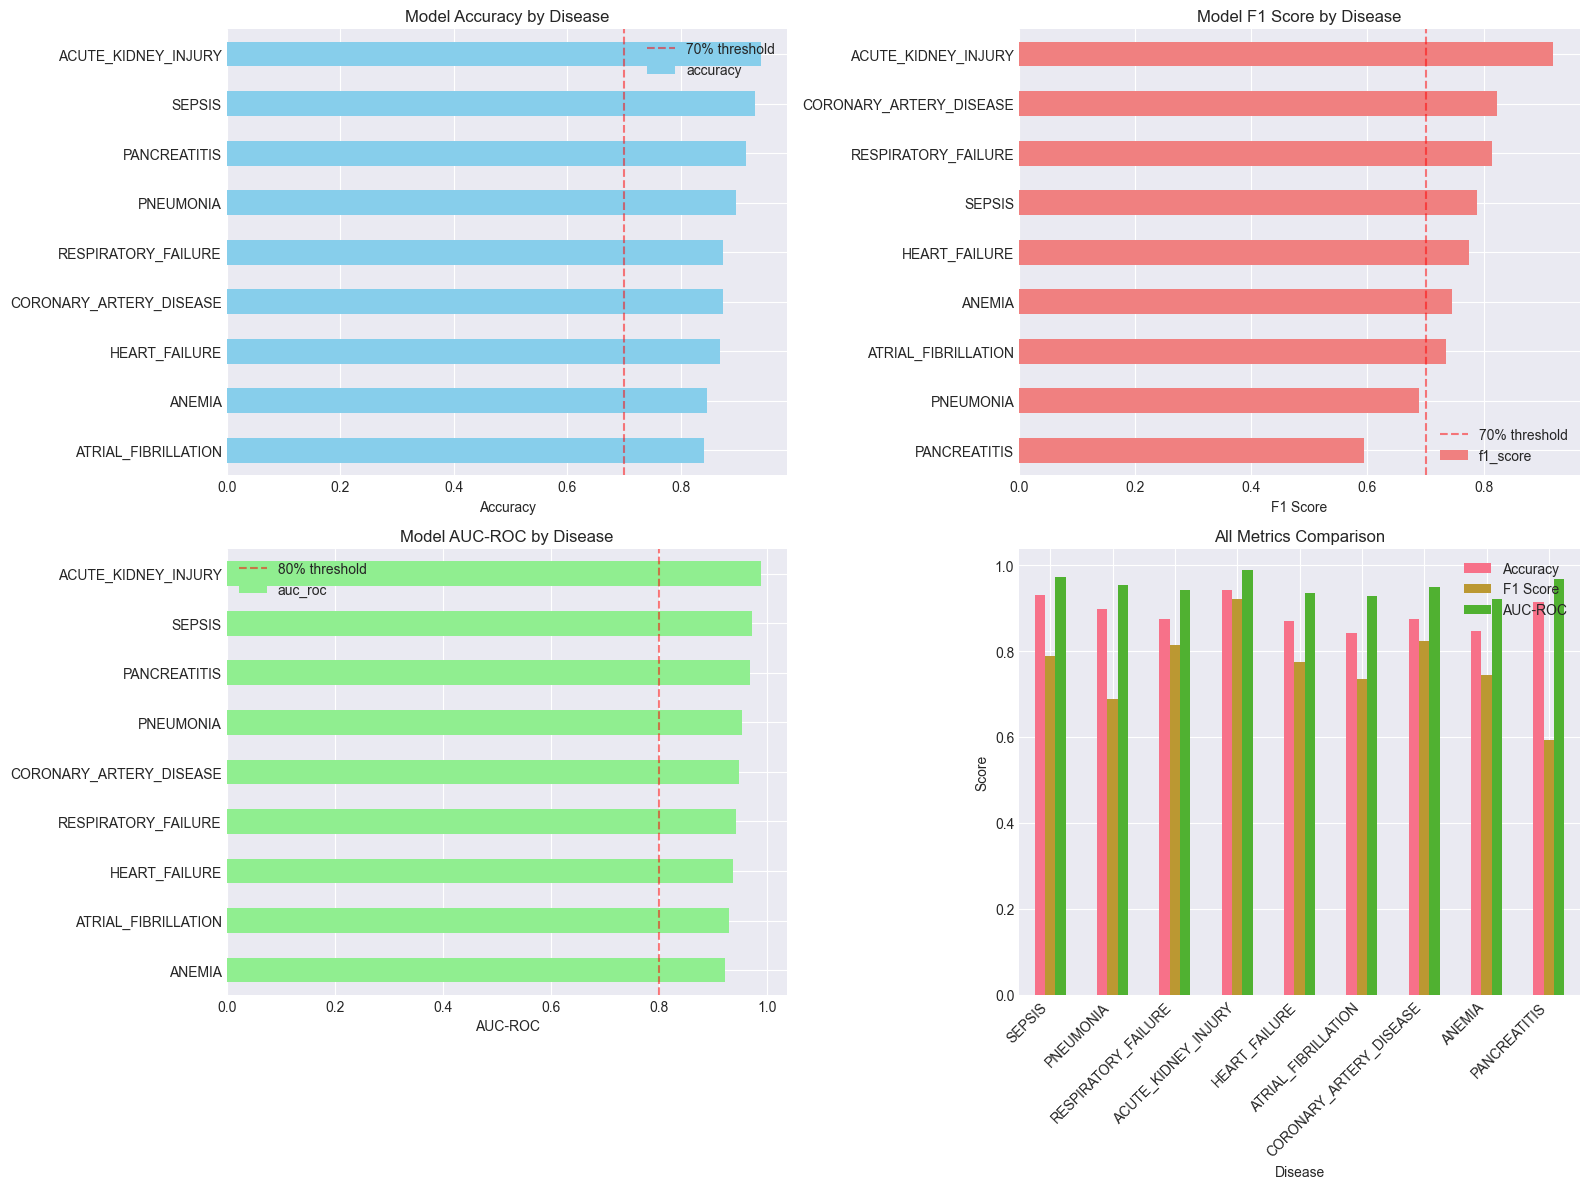

✅ Saved plot: results/agent1_performance.png


In [13]:
print("📊 Creating performance visualizations...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy by Disease
ax1 = axes[0, 0]
metrics_df.sort_values('accuracy')['accuracy'].plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy by Disease')
ax1.axvline(x=0.7, color='r', linestyle='--', alpha=0.5, label='70% threshold')
ax1.legend()

# Plot 2: F1 Score by Disease
ax2 = axes[0, 1]
metrics_df.sort_values('f1_score')['f1_score'].plot(kind='barh', ax=ax2, color='lightcoral')
ax2.set_xlabel('F1 Score')
ax2.set_title('Model F1 Score by Disease')
ax2.axvline(x=0.7, color='r', linestyle='--', alpha=0.5, label='70% threshold')
ax2.legend()

# Plot 3: AUC-ROC by Disease
ax3 = axes[1, 0]
metrics_df.sort_values('auc_roc')['auc_roc'].plot(kind='barh', ax=ax3, color='lightgreen')
ax3.set_xlabel('AUC-ROC')
ax3.set_title('Model AUC-ROC by Disease')
ax3.axvline(x=0.8, color='r', linestyle='--', alpha=0.5, label='80% threshold')
ax3.legend()

# Plot 4: All metrics comparison
ax4 = axes[1, 1]
metrics_df[['accuracy', 'f1_score', 'auc_roc']].plot(kind='bar', ax=ax4)
ax4.set_xlabel('Disease')
ax4.set_ylabel('Score')
ax4.set_title('All Metrics Comparison')
ax4.legend(['Accuracy', 'F1 Score', 'AUC-ROC'])
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../../results/agent1_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot: results/agent1_performance.png")

In [14]:
print("🔍 Analyzing feature importance...")
print("=" * 60)

# Extract feature importance for each disease
feature_importance = {}

for disease in disease_cols:
    # Get feature importance from model
    importance = models[disease].feature_importances_
    
    # Create dataframe
    imp_df = pd.DataFrame({
        'feature': X_scaled.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    feature_importance[disease] = imp_df
    
    print(f"\n{disease}:")
    print(f"  Top 10 important features:")
    for idx, row in imp_df.head(10).iterrows():
        print(f"    {row['feature']:20s}: {row['importance']:.4f}")

print(f"\n✅ Feature importance analyzed for all diseases")

🔍 Analyzing feature importance...

SEPSIS:
  Top 10 important features:
    lab_50813_count     : 0.0888
    lab_50893_min       : 0.0549
    lab_50885_count     : 0.0277
    lab_50821_mean      : 0.0208
    lab_50889_count     : 0.0133
    lab_50820_count     : 0.0132
    lab_50863_max       : 0.0130
    lab_50821_max       : 0.0120
    lab_50882_count     : 0.0113
    lab_51301_std       : 0.0103

PNEUMONIA:
  Top 10 important features:
    lab_50970_count     : 0.1312
    lab_50818_count     : 0.0344
    lab_50821_count     : 0.0336
    lab_50821_mean      : 0.0311
    lab_50893_count     : 0.0160
    lab_50821_min       : 0.0145
    lab_50813_count     : 0.0120
    lab_50882_max       : 0.0117
    lab_50821_max       : 0.0115
    lab_50868_count     : 0.0097

RESPIRATORY_FAILURE:
  Top 10 important features:
    lab_50818_count     : 0.2632
    lab_50821_count     : 0.0514
    lab_50813_count     : 0.0343
    lab_50818_max       : 0.0283
    lab_50821_std       : 0.0265
    lab_509

📊 Creating feature importance visualizations...


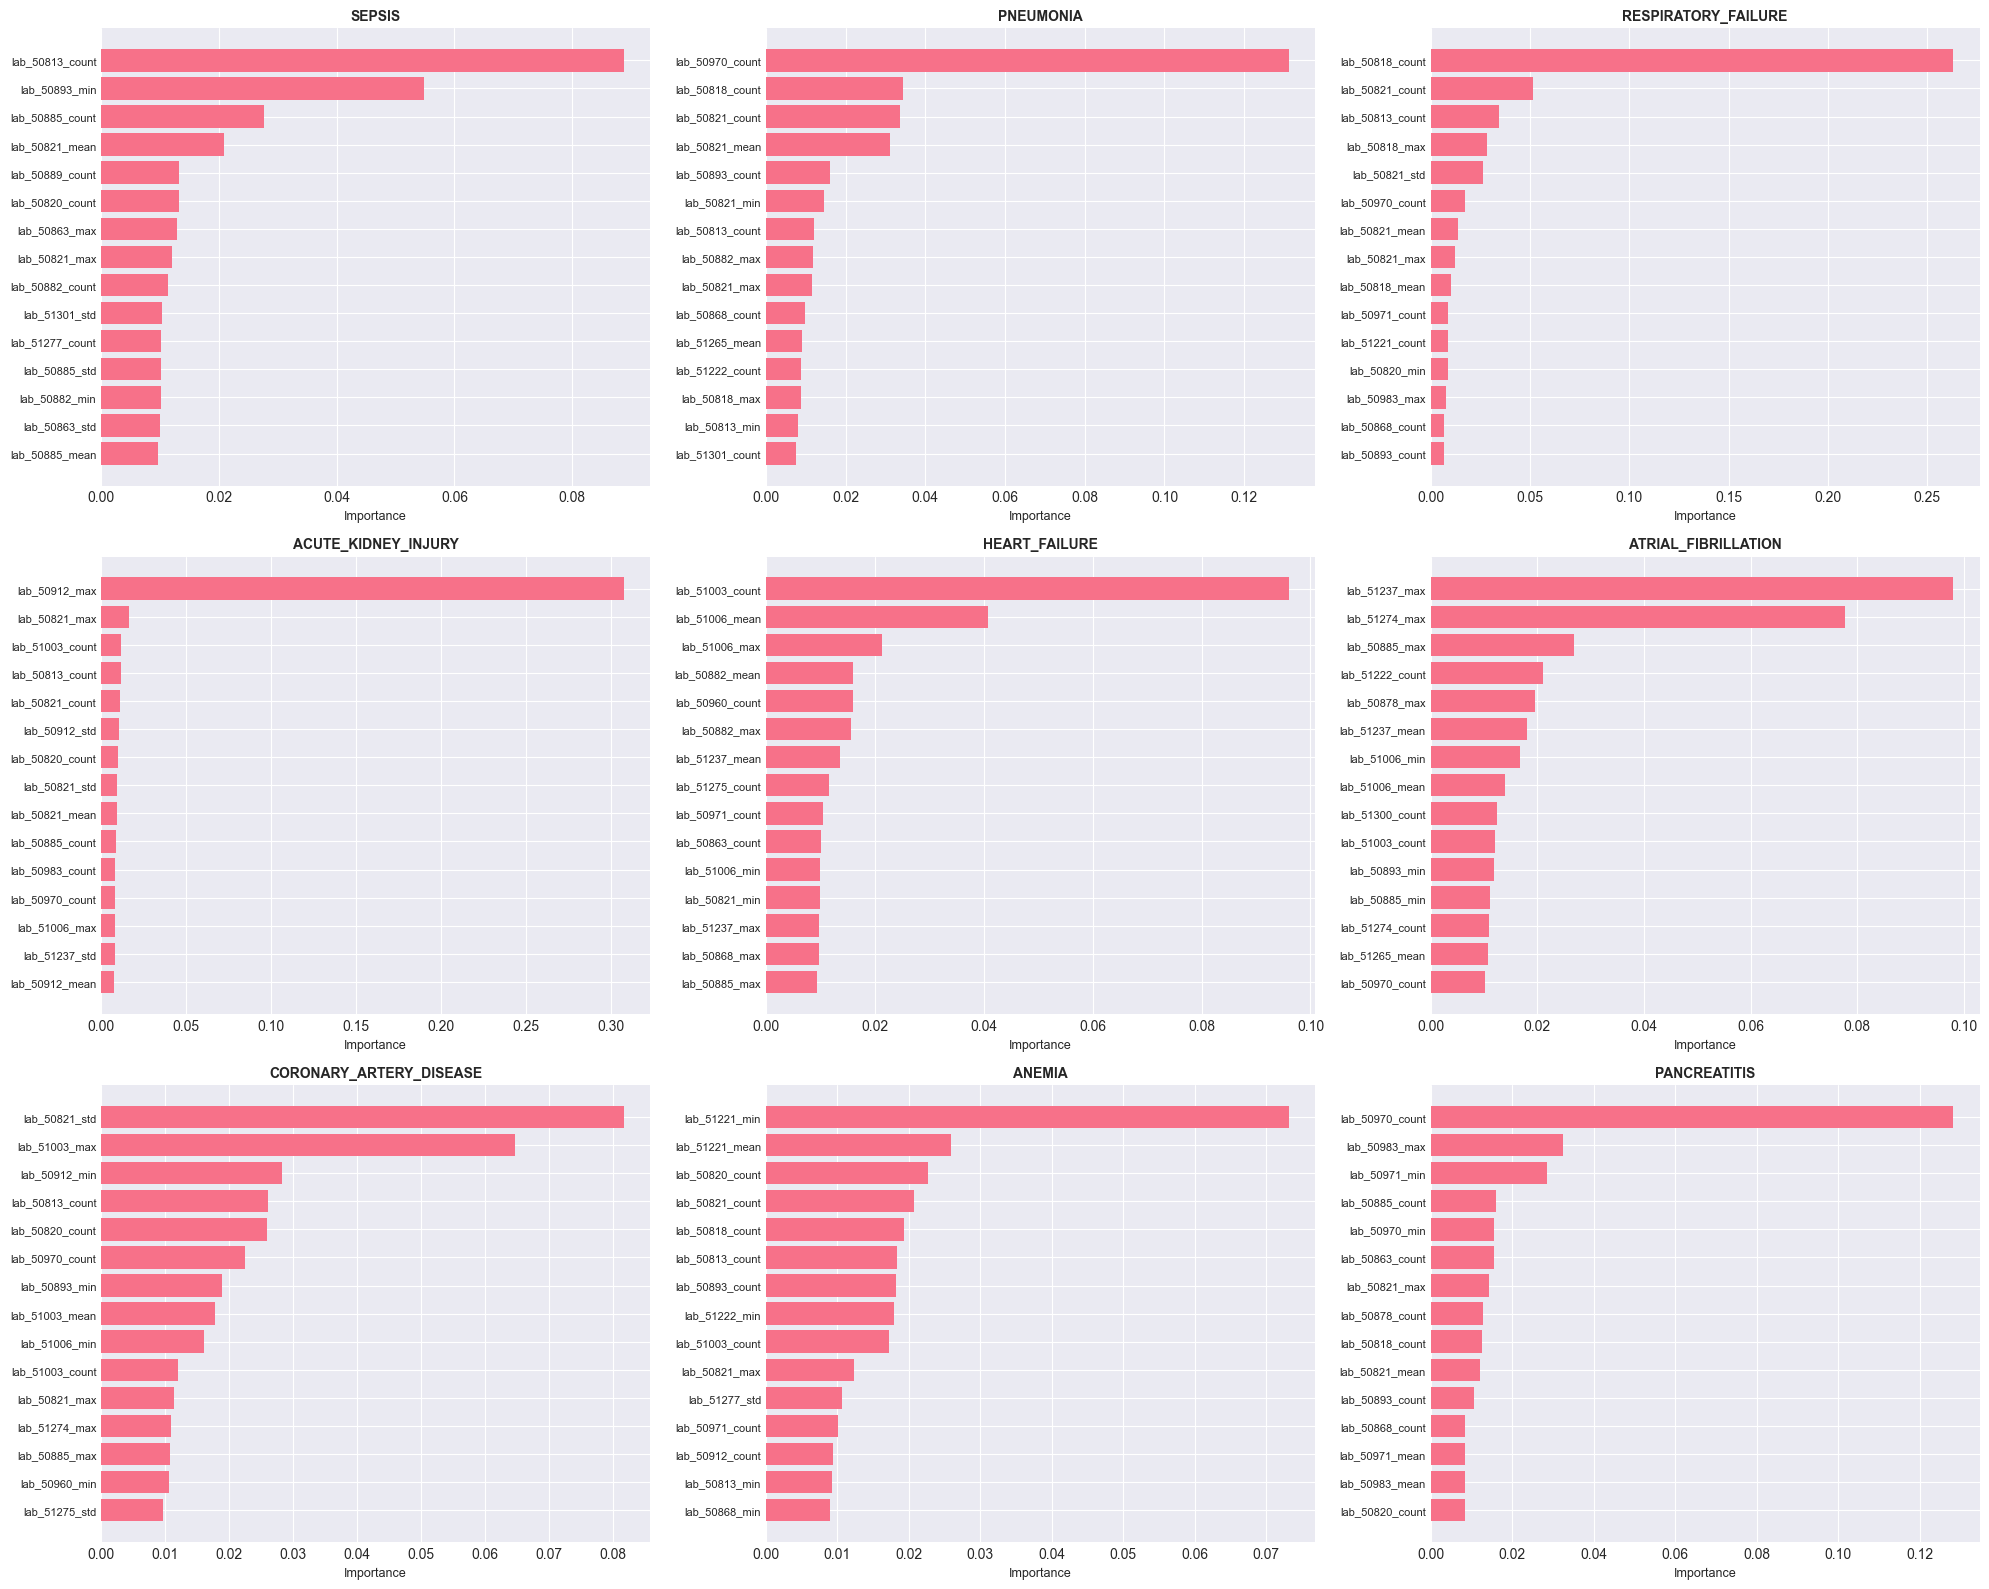

✅ Saved plot: results/agent1_feature_importance.png


In [15]:
print("📊 Creating feature importance visualizations...")
print("=" * 60)

# Create subplot for each disease
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, disease in enumerate(disease_cols):
    ax = axes[idx]
    
    # Get top 15 features
    top_features = feature_importance[disease].head(15)
    
    # Plot
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values, fontsize=8)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f'{disease}', fontsize=10, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../results/agent1_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot: results/agent1_feature_importance.png")

In [16]:
print("💾 Saving models and preprocessing objects...")
print("=" * 60)

import joblib

# Save models
for disease, model in models.items():
    filename = f'../../models/agent1_{disease.lower()}.joblib'
    joblib.dump(model, filename)
    print(f"  ✅ Saved: {filename}")

# Save preprocessing objects
joblib.dump(imputer, '../../models/agent1_imputer.joblib')
joblib.dump(scaler, '../../models/agent1_scaler.joblib')

# Save feature names and dropped features
preprocessing_info = {
    'features_used': X_scaled.columns.tolist(),
    'features_dropped': features_to_drop,
    'n_features': X_scaled.shape[1],
    'imputation_strategy': 'median',
    'scaling_method': 'StandardScaler'
}

import json
with open('../../models/agent1_preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

print(f"\n✅ Saved preprocessing objects:")
print(f"  - Imputer: models/agent1_imputer.joblib")
print(f"  - Scaler: models/agent1_scaler.joblib")
print(f"  - Info: models/agent1_preprocessing_info.json")

print(f"\n🎉 All models and objects saved!")

💾 Saving models and preprocessing objects...
  ✅ Saved: ../models/agent1_sepsis.joblib
  ✅ Saved: ../models/agent1_pneumonia.joblib
  ✅ Saved: ../models/agent1_respiratory_failure.joblib
  ✅ Saved: ../models/agent1_acute_kidney_injury.joblib
  ✅ Saved: ../models/agent1_heart_failure.joblib
  ✅ Saved: ../models/agent1_atrial_fibrillation.joblib
  ✅ Saved: ../models/agent1_coronary_artery_disease.joblib
  ✅ Saved: ../models/agent1_anemia.joblib
  ✅ Saved: ../models/agent1_pancreatitis.joblib

✅ Saved preprocessing objects:
  - Imputer: models/agent1_imputer.joblib
  - Scaler: models/agent1_scaler.joblib
  - Info: models/agent1_preprocessing_info.json

🎉 All models and objects saved!


In [8]:
# Check what variables we have
print("📋 Available DataFrames:")
for var_name in dir():
    if not var_name.startswith('_'):
        var_value = eval(var_name)
        if isinstance(var_value, pd.DataFrame):
            print(f"  • {var_name}: {var_value.shape}")
            if 'SUBJECT_ID' in var_value.columns:
                print(f"    → Has SUBJECT_ID! ✅")
                print(f"    → Columns: {var_value.columns.tolist()[:5]}...")

📋 Available DataFrames:
  • lab_features: (21794, 156)
    → Has SUBJECT_ID! ✅
    → Columns: ['SUBJECT_ID', 'lab_51301_mean', 'lab_51301_min', 'lab_51301_max', 'lab_51301_std']...


In [9]:
# Save lab data for interface evidence
lab_features.to_csv('../../data/processed/lab_features_with_subject_id.csv', index=False)

print("✅ Saved lab_features_with_subject_id.csv")
print(f"   Shape: {lab_features.shape}")
print(f"   Total: {lab_features.shape[0]} patients, {lab_features.shape[1]-1} lab features")

✅ Saved lab_features_with_subject_id.csv
   Shape: (21794, 156)
   Total: 21794 patients, 155 lab features


In [11]:
# Check what validation file exists
import os
from pathlib import Path

print("Checking for validation lab features...")

if Path('../../data/processed/lab_features_val.csv').exists():
    labs_val = pd.read_csv('../../data/processed/lab_features_val.csv')
    print(f"✅ Found lab_features_val.csv: {labs_val.shape}")
    print(f"   Has SUBJECT_ID: {'SUBJECT_ID' in labs_val.columns}")
else:
    print("❌ lab_features_val.csv not found!")
    print("\n💡 We need to create the validation split")
    print("   Do you have a notebook where you split data into train/val/test?")

Checking for validation lab features...
✅ Found lab_features_val.csv: (4675, 156)
   Has SUBJECT_ID: True
